<a href="https://colab.research.google.com/github/dhkdsns20/Capstone-Design/blob/main/Path_finding_Algorithm_final_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Path Finding Algorithm
## Find strongest path with thpt

In [1]:
!pip install osmnx



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 9.2 MB/s eta 0:00:00


In [ ]:
!pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/b1/79/0d1c165eac44405a86478082e225fce87874f7198300bbebc55faaf6d28d/matplotlib-3.10.3-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/01/c8/fadd0b92ffa7b5eb5949bf340a63a4a496a6930a6c37a7ba0f12acb076d6/contourpy-1.3.2-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/06/5d/1be5424bb305880e1113631f49a55ea7c7da3a5fe02608ca7c16a03a21da/fonttools-4.57.0-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/104.6 kB ? eta -:--:--
     --------------- ----------------------- 41.0/104.6 kB 2.0 MB/s 


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install folium

  Obtaining dependency information for folium from https://files.pythonhosted.org/packages/81/4d/bcbee0676dc06f0b014a030cb928e158c96daafb872a01ddee7e60a8c998/folium-0.19.5-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.6.0 from https://files.pythonhosted.org/packages/f8/9d/91cddd38bd00170aad1a4b198c47b4ed716be45c234e09b835af41f4e717/branca-0.8.1-py3-none-any.whl.metadata
  Obtaining dependency information for xyzservices from https://files.pythonhosted.org/packages/d6/7d/b77455d7c7c51255b2992b429107fab811b2e36ceaf76da1e55a045dc568/xyzservices-2025.4.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/110.9 kB ? eta -:--:--
   --- ------------------------------------ 10.2/110.9 kB ? eta -:--:--
   ------------------------------------ --- 102.4/110.9 kB 2.0 MB/s eta 0:00:01
   ---------------------------------------- 110.9/110.9 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/90.4 kB ? eta -:--:--
   --------


[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# 노드 관련 함수


# from pyrosm import OSM
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import folium
import heapq

#  출발지 및 목적지 노드 설정 함수 정의
def get_nearest_node(G, latitude, longitude):
    """
    입력된 위도와 경도에 가장 가까운 그래프 노드를 찾는 함수.

    - G: 도로 네트워크 그래프
    - latitude: 위도
    - longitude: 경도

    반환: 가장 가까운 노드 ID
    """
    return ox.distance.nearest_nodes(G, longitude, latitude)

# 최단 경로 탐색 함수 정의
def find_shortest_path(G, origin_point, destination_point):
    """
    입력된 출발지와 목적지 간 최단 경로를 찾는 함수.

    - G: 도로 네트워크 그래프
    - origin_point: 출발지 좌표 (위도, 경도)
    - destination_point: 목적지 좌표 (위도, 경도)

    반환: 최단 경로 노드 리스트
    """
    # # 출발지와 목적지의 가장 가까운 노드 찾기
    # origin_node = get_nearest_node(G, *origin_point)
    # destination_node = get_nearest_node(G, *destination_point)

    # 최단 경로 계산 (Dijkstra 알고리즘)
    shortest_path = nx.shortest_path(G, origin_point, destination_point, weight='length',method="dijkstra") #
    return shortest_path


def plot_route(G, path):
    """
    최단 경로를 그래프에 시각화하는 함수.

    - G: 도로 네트워크 그래프
    - path: 최단 경로 노드 리스트
    """
    if path is None or len(path) == 0:
        print("경로가 유효하지 않아 시각화를 생략합니다.")
        return

    try:
        fig, ax = ox.plot_graph_route(G, path, route_linewidth=2, node_size=0, bgcolor='k')
        plt.show()
    except Exception as e:
        print(f"경로 시각화 중 오류 발생: {e}")


# 도로만 남기는 함수
def create_filtered_graph(G, excluded_highway_types):
    """
    특정 highway 유형을 제외한 새로운 그래프를 반환하는 함수.

    - G: NetworkX 그래프
    - excluded_highway_types: 제외할 highway 유형 리스트 (예: ['footway'])

    반환: 제외된 엣지가 제거된 새로운 NetworkX 그래프
    """
    # 그래프 복사 (원본을 유지하기 위해)
    filtered_graph = G.copy()

    # 제거 대상 엣지 식별 및 제거
    edges_to_remove = [
        (u, v) for u, v, data in filtered_graph.edges(data=True)
        if data.get('highway') in excluded_highway_types
    ]
    filtered_graph.remove_edges_from(edges_to_remove)

    # print(f"Removed {len(edges_to_remove)} edges with highway types: {excluded_highway_types}")
    return filtered_graph

# 도로 네트워크 시각화 함수 정의 (Node ID 표시 추가) - 추가기능
def plot_map_with_node_ids(G, poi_coords=None):
    """
    도로 네트워크와 각 노드의 ID를 시각화하는 함수.

    - G: 도로 네트워크 그래프
    - poi_coords: POI 위치 좌표 리스트 (선택적)
    """
    # 도로 네트워크 시각화
    fig, ax = ox.plot_graph(G, show=False, close=False)

    i = 1
    # 각 노드의 위치에 Node ID를 표시
    for node, data in G.nodes(data=True):
        x, y = data['x'], data['y']
        if node == 10666146667 or node == 9274780719:
            ax.text(x, y, str(node), fontsize=8, color='blue')  # Node ID 표시

    # POI 위치 시각화 (있을 경우)
    if poi_coords:
        y, x = zip(*poi_coords)
        ax.scatter(x, y, c='red', s=30, label='POI')
        ax.legend()

    plt.show()

# throughput 데이터를 노드에 매핑하는 함수 정의
def map_throughput_to_nodes(G, throughput_excel):
    """
    throughput 데이터를 그래프 노드 속성으로 매핑하는 함수.

    - G: 도로 네트워크 그래프
    - throughput_excel: 노드 ID와 throughput 값을 가진 DataFrame

    반환: throughput 속성이 추가된 그래프
    """
    # 노드 ID를 문자열로 변환하여 통일
    throughput_excel['Node ID'] = throughput_excel['Node ID'].astype(str)

    for node, data in G.nodes(data=True):
        # 그래프 노드 ID도 문자열로 변환
        node_str = str(node)
        # 노드 ID와 일치하는 Throughput 값을 찾음
        throughput_value = throughput_excel.loc[throughput_excel['Node ID'] == node_str, 'Throughput(Mbps)'].values
        if len(throughput_value) > 0:
            G.nodes[node]['throughput'] = throughput_value[0]  # Throughput 값을 노드에 추가
        else:
            G.nodes[node]['throughput'] = 0  # 데이터가 없을 경우 0으로 설정
    return G


## 그래프 확인

In [ ]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# 간선 & 가중치 관련 함수


# 누적 가중치를 고려한 함수
def find_strongest_path(G, source, target):
    """
    Dijkstra 알고리즘을 수정하여 누적 가중치를 고려한 경로를 찾는 함수.

    - G: NetworkX 그래프
    - source: 출발 노드
    - target: 도착 노드

    반환:
    - 최단 경로의 노드 리스트
    - 경로의 누적 가중치
    """
    # 우선순위 큐 초기화 (누적 가중치 기준)
    queue = [(0, source, [])]  # (누적 가중치, 현재 노드, 경로)
    visited = set()

    while queue:
        cum_weight, current_node, path = heapq.heappop(queue)

        # 이미 방문한 노드는 무시
        if current_node in visited:
            continue
        visited.add(current_node)

        # 현재 노드를 경로에 추가
        path = path + [current_node]

        # 목표 노드에 도달하면 결과 반환
        if current_node == target:
            return path, cum_weight

        # 인접 노드 탐색
        for neighbor in G.neighbors(current_node):
            edge_data = G[current_node][neighbor]

            # ✅ 단일 간선 딕셔너리 접근 — Graph 타입에서는 이렇게 직접 접근해야 함
            edge_weight = edge_data.get('weight', float('inf'))

            # ✅ 유효한 가중치일 경우에만 큐에 추가
            if edge_weight < float('inf'):
                new_cum_weight = cum_weight + edge_weight
                heapq.heappush(queue, (new_cum_weight, neighbor, path))

            # # 최소 가중치 선택 (다중 간선 고려)
            # min_edge_weight = float('inf')
            # for key, data in edge_data.items():
            #     edge_weight = data.get('weight', float('inf'))
            #     if edge_weight is not None:
            #         min_edge_weight = min(min_edge_weight, edge_weight)

            # # 최소 가중치를 기반으로 경로 확장
            # if min_edge_weight < float('inf'):
            #     new_cum_weight = cum_weight + min_edge_weight
            #     heapq.heappush(queue, (new_cum_weight, neighbor, path))

    return None, float('inf')




# 가중치 계산 함수
def calculate_weight(throughput, distance, ratio):
    """
    - Throughput : Throughput 값
    - distance   : distance 값
    - ratio      : Throughput과 거리의 비율 (0~1)

    """
    # 최종 가중치 계산
    # 전처리 이전: weight = (ratio * throughput) + ((1 - ratio) * distance)
    # 전처리 이후
    weight = (ratio * (1-throughput)) + ((1 - ratio) * distance)
    return weight




# 간선 가중치 설정 함수
def set_edge_weights_based_on_ratio(G, ratio):
    """
    간선의 가중치를 두 노드의 throughput 값과 거리 값의 비율로 설정하는 함수.
    - G: 도로 네트워크 그래프
    - ratio: Throughput:Distance 비율 (0~1)
    """

    for u, v, data in G.edges(data=True):
        # 노드의 throughput 값을 가져옴 (없으면 0으로 설정)
        throughput_u = G.nodes[u].get('throughput', 0)
        throughput_v = G.nodes[v].get('throughput', 0)
        distance = data.get('length', float('inf'))

        # 두 노드의 throughput 평균 계산
        avg_throughput = (throughput_u + throughput_v) / 2
        weight = calculate_weight(avg_throughput, distance, ratio)
        data['weight'] = weight
    return G


- 충북대 osm 불러오기 및 src, target 지정

출발지 노드 ID (청주 시외버스터미널): 8485871892
목적지 노드 ID (충북대학교 병원): 6200628380


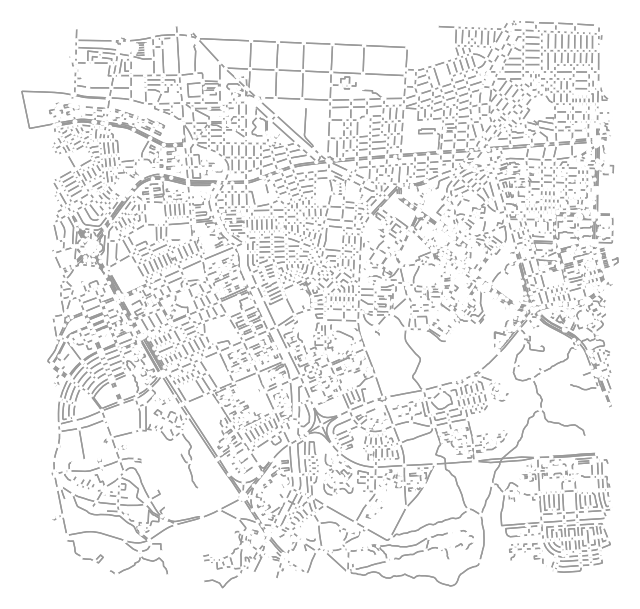

In [4]:
# 출발지 및 목적지 좌표 설정
origin = (36.6256453, 127.4314837)        # 청주 시외버스터미널
destination = (36.6246818, 127.4638686)   # 충북대학교 병원

# 중심 좌표 계산 (중간 지점)
center_lat = (origin[0] + destination[0]) / 2
center_lon = (origin[1] + destination[1]) / 2
center_point = (center_lat, center_lon)

# 반경 2km 도로 네트워크 불러오기
radius = 2000  # 반경 2km
cheongju_graph = ox.graph_from_point(center_point, dist=radius, network_type="walk")

# 출발지와 목적지의 가장 가까운 노드 찾기
origin_node = get_nearest_node(cheongju_graph, *origin)
destination_node = get_nearest_node(cheongju_graph, *destination)

print(f"출발지 노드 ID (청주 시외버스터미널): {origin_node}")
print(f"목적지 노드 ID (충북대학교 병원): {destination_node}")

# 시각화로 반경 확인
fig, ax = ox.plot_graph(cheongju_graph, bgcolor='white', node_size=10, edge_linewidth=1)

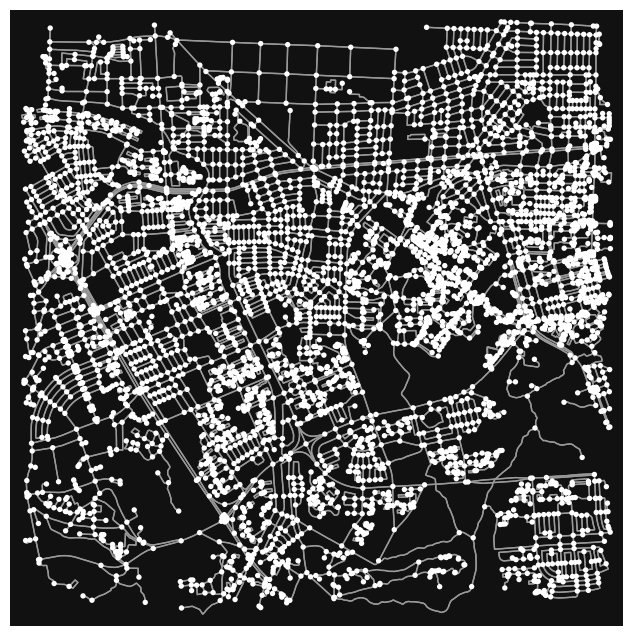

In [5]:
## 도보 제외한 네트워크 Graph 생성
# 제외할 highway 유형 설정
excluded_highways = ['footway']

# 필터링된 그래프 생성
filtered_graph = create_filtered_graph(cheongju_graph, excluded_highways)

plot_map_with_node_ids(filtered_graph)

## 유효 노드 (교차로 사이 노드 포함 : 도로생성을 위해서)

In [6]:
pip install openpyxl


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

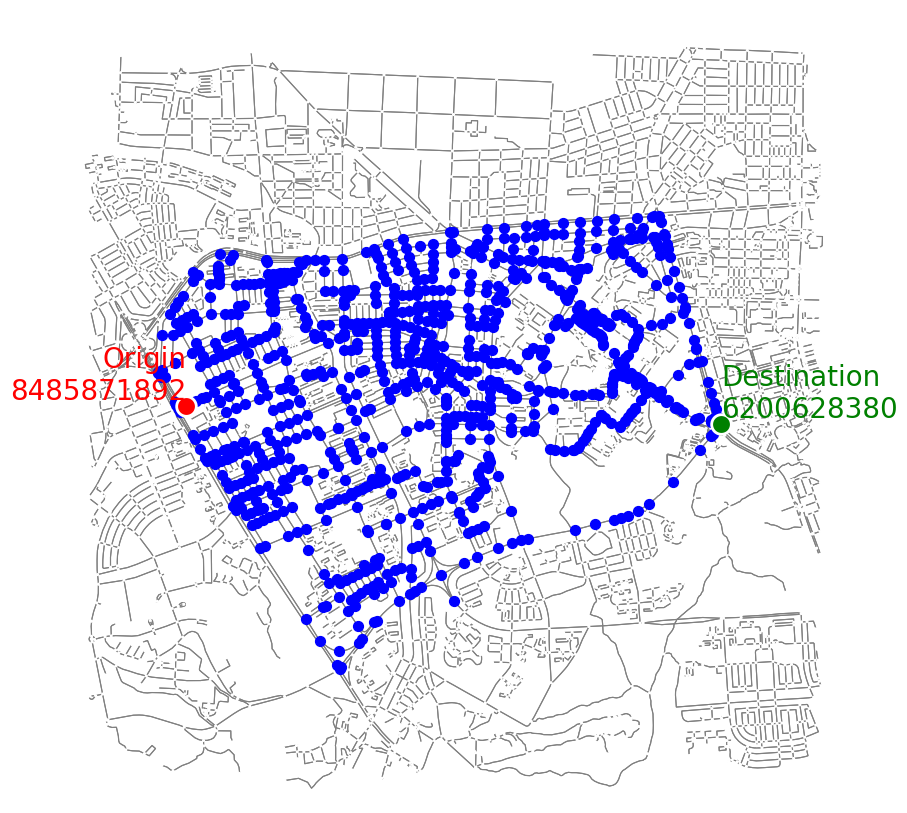

In [10]:
# 단계 1 : 기본 유효 노드 집합 생성
# Rx 노드 ID 불러오기
rx_file_path = 'all_nodes_with_coordinates_throughput.xlsx'
rx_data = pd.read_excel(rx_file_path)
rx_node_ids = rx_data['Node ID'].tolist()

# 출발지 및 목적지 좌표 설정
origin = (36.6256453, 127.4314837)        # 청주 시외버스터미널
destination = (36.6246818, 127.4638686)   # 충북대학교 병원

# # OSM 데이터 로드
# cheongju_graph = ox.graph_from_place('Cheongju, South Korea', network_type='drive')

# 출발지와 목적지의 가장 가까운 노드 찾기
# origin_node = ox.distance.nearest_nodes(cheongju_graph, origin[1], origin[0])
# destination_node = ox.distance.nearest_nodes(cheongju_graph, destination[1], destination[0])

origin_node = ox.distance.nearest_nodes(filtered_graph, origin[1], origin[0])
destination_node = ox.distance.nearest_nodes(filtered_graph, destination[1], destination[0])

# # 출발지, 목적지, Rx 노드 ID 합치기
# valid_node_ids = set(rx_node_ids + [origin_node, destination_node])


# Rx 노드만 포함된 독립 그래프 생성
rx_graph = nx.Graph()
for _, row in rx_data.iterrows():
    node_id = row['Node ID']
    lat, lon = row['Latitude'], row['Longitude']
    rx_graph.add_node(node_id, x=lon, y=lat)


# 출발지, 목적지, Rx 노드만 포함하는 필터링된 그래프 생성
# node_filtered_graph = cheongju_graph.subgraph(rx_node_ids).copy()
node_filtered_graph = filtered_graph.subgraph(rx_node_ids).copy()


# 유효 노드들로 구성된 도로 찾기
valid_edges = []
for u, v, data in node_filtered_graph.edges(data=True):
    if u in rx_node_ids and v in rx_node_ids:  # Rx 노드 간 연결만 포함
        valid_edges.append((u, v))

# 유효 노드와 도로 시각화 개선
valid_graph = nx.Graph()
valid_graph.add_edges_from(valid_edges)
valid_graph.add_nodes_from(rx_node_ids)

# 빠른 시각화 함수
def plot_fast_graph(G, rx_graph, origin_node, destination_node):
    fig, ax = plt.subplots(figsize=(10,10))
    ox.plot_graph(G, ax=ax, node_size=5, node_color='white', edge_color='gray', edge_linewidth=0.8, show=False, close=False, bgcolor='black')

    # Rx 노드 시각화
    for node in rx_graph.nodes:
        x, y = rx_graph.nodes[node]['x'], rx_graph.nodes[node]['y']
        ax.scatter(x, y, c='blue', s=50, marker='o')
        #ax.text(x + 0.0001, y + 0.0001, str(node), fontsize=8, color='blue')

    # 출발지 노드 표시
    x, y = G.nodes[origin_node]['x'], G.nodes[origin_node]['y']
    ax.scatter(x, y, c='red', s=200, label='Origin', marker='o', edgecolors='white', linewidths=2)
    ax.text(x, y, f'Origin\n{origin_node}', fontsize=20, color='red', ha='right', va='bottom')

    # 목적지 노드 표시
    x, y = G.nodes[destination_node]['x'], G.nodes[destination_node]['y']
    ax.scatter(x, y, c='green', s=200, label='Destination', marker='o', edgecolors='white', linewidths=2)
    ax.text(x, y, f'Destination\n{destination_node}', fontsize=20, color='green', ha='left', va='bottom')

    plt.title("도로 네트워크와 Rx 노드 시각화 (OSMnx + Matplotlib)", color='white', fontsize=14)
    plt.show()

# 시각화 실행
plot_fast_graph(filtered_graph, rx_graph, origin_node, destination_node)


In [ ]:
# 유효노드 분석 및 파일 내보내기

# 출발지와 도착지를 별도로 관리
origin_destination_ids = {origin_node, destination_node}

# Rx 노드 (rx_graph 노드) 집합화
rx_only_node_ids = set(rx_graph.nodes)

# 전체 유효 노드
valid_node_ids = rx_only_node_ids | origin_destination_ids  # 합집합

# 출력
print(f"✅ Rx 노드 수: {len(rx_only_node_ids)}개")
print(f"✅ 출발지, 도착지 노드 수: {len(origin_destination_ids)}개")
print(f"✅ 전체 유효 노드 수 (Rx + 출발지/도착지): {len(valid_node_ids)}개")


✅ Rx 노드 수: 970개
✅ 출발지, 도착지 노드 수: 2개
✅ 전체 유효 노드 수 (Rx + 출발지/도착지): 970개


In [ ]:
def save_only_rx_nodes_with_coordinates(rx_graph, output_path):
    """
    Rx 노드만 Node ID + 위도(latitude) + 경도(longitude)를 엑셀로 저장하는 함수
    (출발지/도착지 노드는 저장하지 않음)
    """
    records = []

    # Rx 노드만 저장 (rx_graph 기준)
    for node in rx_graph.nodes:
        x = rx_graph.nodes[node].get('x', None)
        y = rx_graph.nodes[node].get('y', None)
        if x is not None and y is not None:
            records.append({'Node ID': node, 'latitude': y, 'longitude': x})

    # 데이터프레임으로 변환 및 엑셀 저장
    df = pd.DataFrame(records)
    df.to_excel(output_path, index=False)
    print(f"✅ 총 {len(records)}개 Rx 노드를 '{output_path}'에 저장했습니다.")

In [ ]:
# 저장 (출발지,목적지 총 2개의 노드는 제외)
save_only_rx_nodes_with_coordinates(
    rx_graph=rx_graph,
    output_path='only_rx_nodes_with_coordinates.xlsx'
)


✅ 총 970개 Rx 노드를 'only_rx_nodes_with_coordinates.xlsx'에 저장했습니다.


- Rx 노드 사이 도로 시각화

유효 간선 3286개, 유효 노드 1165개 추출 완료.


c:\Users\601_PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\601_PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\601_PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45348 (\N{HANGUL SYLLABLE NE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\601_PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\601_PC\AppData\Local\Programs\Python\Python313\Lib\site-packag

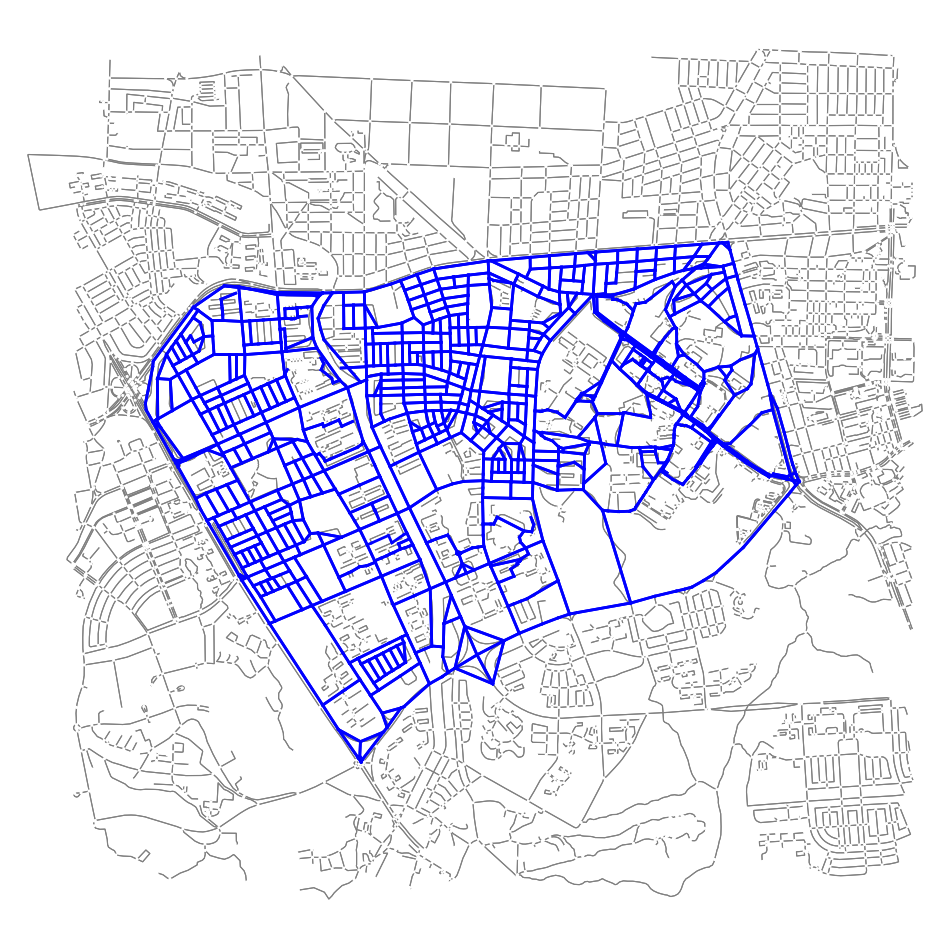

In [ ]:
# 출발지/도착지 제거된 Rx 노드만 포함
valid_node_ids = set(rx_only_node_ids)  # Rx 노드만

valid_edges = set()  # 중복 방지용 set으로 변경

# 전체 Rx 노드 리스트
rx_nodes = rx_node_ids

# Rx 노드별로 최단 경로 계산 (단일 실행으로 개선)
for i, u in enumerate(rx_nodes):
    lengths, paths = nx.single_source_dijkstra(cheongju_graph, source=u, weight='length')

    for j in range(i + 1, len(rx_nodes)):
        v = rx_nodes[j]
        if v in paths:
            path = paths[v]
            # 경로 상 간선과 노드 추가
            for k in range(len(path) - 1):
                valid_edges.add((path[k], path[k+1]))
                valid_node_ids.update([path[k], path[k+1]])

# 그래프 구성
valid_graph = nx.Graph()
valid_graph.add_edges_from(valid_edges)
# valid_graph.add_nodes_from(valid_node_ids)

# 추가로 노드 속성도 같이 복사
for node_id in valid_node_ids:
    if node_id in cheongju_graph.nodes:
        node_attrs = cheongju_graph.nodes[node_id]
        valid_graph.add_node(node_id, **node_attrs)

print(f"유효 간선 {len(valid_edges)}개, 유효 노드 {len(valid_node_ids)}개 추출 완료.")



# 시각화 함수 (Rx 노드 간 도로 포함)
def plot_fast_graph(G, rx_graph, origin_node, destination_node):
    fig, ax = plt.subplots(figsize=(12, 12))
    ox.plot_graph(G, ax=ax, node_size=5, node_color='white', edge_color='gray', edge_linewidth=0.8, show=False, close=False, bgcolor='black')

    # # Rx 노드 시각화
    # for node in rx_graph.nodes:
    #     x, y = rx_graph.nodes[node]['x'], rx_graph.nodes[node]['y']
    #     ax.scatter(x, y, c='blue', s=50, marker='x')
    #     ax.text(x + 0.0001, y + 0.0001, str(node), fontsize=8, color='blue')

    # # 출발지 노드 표시
    # x, y = G.nodes[origin_node]['x'], G.nodes[origin_node]['y']
    # ax.scatter(x, y, c='red', s=100, label='Origin', marker='o', edgecolors='white', linewidths=2)
    # ax.text(x, y, f'Origin\n{origin_node}', fontsize=10, color='red', ha='left', va='bottom')

    # # 목적지 노드 표시
    # x, y = G.nodes[destination_node]['x'], G.nodes[destination_node]['y']
    # ax.scatter(x, y, c='green', s=100, label='Destination', marker='o', edgecolors='white', linewidths=2)
    # ax.text(x, y, f'Destination\n{destination_node}', fontsize=10, color='green', ha='left', va='bottom')

    # Rx 노드 사이 도로 시각화
    for u, v in valid_edges:
        x1, y1 = G.nodes[u]['x'], G.nodes[u]['y']
        x2, y2 = G.nodes[v]['x'], G.nodes[v]['y']
        ax.plot([x1, x2], [y1, y2], color='blue', linewidth=2)

    plt.title("도로 네트워크와 Rx 노드 연결 경로 시각화", color='white', fontsize=14)
    plt.show()

# 시각화 실행
plot_fast_graph(cheongju_graph, rx_graph, origin_node, destination_node)


- 간선이 유효노드를 잇고 있는지 확인

In [ ]:
def verify_filtered_edges_connection(filtered_edges, valid_node_ids):
    """
    filtered_edges: 필터링된 trunk 간선 리스트
    valid_node_ids: 연결이 잘 되어야 하는 유효 노드 리스트/집합
    """
    # 1. 필터링된 간선으로 그래프 생성
    G_check = nx.Graph()
    G_check.add_edges_from(filtered_edges)

    # 2. 연결 컴포넌트 찾기
    components = list(nx.connected_components(G_check))

    # 3. 유효 노드들이 같은 컴포넌트에 있는지 확인
    for comp in components:
        if set(valid_node_ids).issubset(comp):
            print(f"✅ 모든 {len(valid_node_ids)}개의 유효 노드가 하나의 연결 컴포넌트 안에 있습니다.")
            return True

    print(f"❌ 유효 노드들이 하나의 연결 컴포넌트에 있지 않습니다.")
    return False

verify_filtered_edges_connection(valid_edges, rx_node_ids)

✅ 모든 970개의 유효 노드가 하나의 연결 컴포넌트 안에 있습니다.


True

### Throughput 매칭
- thpt dataset 불러오기

In [ ]:
# 엑셀 comm data(throughput) 불러오기
throughput_excel = pd.read_excel(r"g:\내 드라이브\[4학년]\[졸업 작품]\all_nodes_with_coordinates_throughput.xlsx")


# throughput 정보를 노드에 매핑
G_set_node = map_throughput_to_nodes(valid_graph, throughput_excel)

- mapping 확인

In [ ]:
def print_throughput_of_valid_nodes(G, rx_node_ids):
    """
    G: throughput이 매핑된 그래프 (G_set_node)
    rx_node_ids: Rx 유효 노드 리스트 또는 집합
    유효 노드들의 처리율(throughput) 값을 출력하는 함수
    """
    count_found = 0
    count_missing = 0

    for node in rx_node_ids:
        if node in G.nodes:
            throughput = G.nodes[node].get('throughput', None)
            if throughput is not None:
                print(f"Node {node}: throughput = {throughput}")
                count_found += 1
            else:
                print(f"❌ Node {node}: throughput 정보 없음")
                count_missing += 1
        else:
            print(f"❌ Node {node}: 그래프에 존재하지 않음")
            count_missing += 1

    print(f"\n✅ 처리율 정보 있는 노드 수: {count_found}개")
    print(f"❌ 처리율 정보 없는 노드 수: {count_missing}개")

print_throughput_of_valid_nodes(G_set_node, rx_node_ids)

Node 3015872343: throughput = 94.8019175459969
Node 4656035229: throughput = 95.53740928833508
Node 3000023775: throughput = 99.0292159901008
Node 4636543383: throughput = 99.05519831471653
Node 4679744568: throughput = 101.6534742301377
Node 3000023509: throughput = 102.41578470307306
Node 4636543376: throughput = 103.00079413626591
Node 4656937191: throughput = 103.14329664222741
Node 4657017758: throughput = 103.17435721096385
Node 3000023440: throughput = 103.34613959495162
Node 3015872375: throughput = 103.92013283245082
Node 3015872364: throughput = 105.03445360054079
Node 3000023812: throughput = 105.21386883968682
Node 2968495409: throughput = 105.42707928019547
Node 4679744909: throughput = 106.67281533552021
Node 2272245054: throughput = 107.03871494229352
Node 3000023442: throughput = 107.36626968222517
Node 3000023511: throughput = 109.21881981522924
Node 4683067432: throughput = 109.8904544727807
Node 4636543387: throughput = 110.20821778822905
Node 4679754838: throughput 

In [ ]:
from haversine import haversine

# 1. 전체 평균 처리율 계산
throughput_values = []
for _, node_data in G_set_node.nodes(data=True):
    t = node_data.get('throughput', None)
    if t is not None and t > 0:
        throughput_values.append(t)

mean_throughput = sum(throughput_values) / len(throughput_values) if throughput_values else 0
print(f"✅ 전체 평균 처리율: {mean_throughput:.3f}")


# 2. 엣지 정보 추출
edges_list = []

for u, v, data in G_set_node.edges(data=True):
    # 거리 추출: 우선순위 'length' → 'distance' → 계산
    distance = data.get('length')
    if distance is None:
        distance = data.get('distance')


    if distance is None:
        # haversine 거리 계산 시도 (좌표가 있을 경우)
        coord_u = (G_set_node.nodes[u].get('y'), G_set_node.nodes[u].get('x'))
        coord_v = (G_set_node.nodes[v].get('y'), G_set_node.nodes[v].get('x'))

        if None not in coord_u and None not in coord_v:
            distance = haversine(coord_u, coord_v) * 1000  # meter 단위로 변환
            #print(f"거리 계산 완료 ({u}, {v}): {distance:.2f} m")
        else:
            distance = None  # 거리 없음 표시
            #print(f"거리 정보 없음: ({u}, {v})")

    # 처리율 (없으면 평균으로 대체)
    throughput_u = G_set_node.nodes[u].get('throughput', 0)
    throughput_v = G_set_node.nodes[v].get('throughput', 0)
    if throughput_u == 0 or throughput_u is None:
        throughput_u = mean_throughput
    if throughput_v == 0 or throughput_v is None:
        throughput_v = mean_throughput

    avg_throughput = (throughput_u + throughput_v) / 2

    edges_list.append({
        '출발 노드': u,
        '도착 노드': v,
        '거리 (m)': distance,
        '노드 u 처리율': throughput_u,
        '노드 v 처리율': throughput_v,
        '평균 처리율': avg_throughput
    })

# 3️⃣ DataFrame으로 변환 후 엑셀 저장
df_edges = pd.DataFrame(edges_list)
df_edges.to_excel("edges_distance_throughput.xlsx", index=False)
print("✅ edges_distance_throughput.xlsx 로 저장 완료!")


✅ 전체 평균 처리율: 141.964
✅ edges_distance_throughput.xlsx 로 저장 완료!


## 데이터 전처리

In [ ]:
!pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# 시각화 함수
import seaborn as sns

def plot_distribution(df, distance_col="distance (m)", throughput_col="Average Throughput"):
    plt.figure(figsize=(14, 5))

    # 거리 분포
    plt.subplot(1, 2, 1)
    sns.histplot(df[distance_col], kde=True, color="skyblue")
    plt.title("Distance", fontsize=14)
    plt.xlabel('distance(m)', fontsize=12)
    plt.ylabel("count", fontsize=12)

    # 처리율 분포
    plt.subplot(1, 2, 2)
    sns.histplot(df[throughput_col], kde=True, color="salmon")
    plt.title("Throughput", fontsize=14)
    plt.xlabel('average Throughput', fontsize=12)
    plt.ylabel("count", fontsize=12)

    plt.tight_layout()
    plt.show()


In [ ]:
# 정규화 함수
from sklearn.preprocessing import MinMaxScaler

def normalize_data(df, distance_col="distance (m)", throughput_col="Average Throughput"):
    df_clean = df[[distance_col, throughput_col]].dropna()  # NaN 제거
    scaler = MinMaxScaler()

    if df_clean.empty:
        print("⚠️ 데이터가 비어있습니다!")
        return df

    norm_values = scaler.fit_transform(df_clean)

    df_norm = df.copy()
    df_norm.loc[df_clean.index, "distance_norm"] = norm_values[:, 0]
    df_norm.loc[df_clean.index, "throughput_norm"] = norm_values[:, 1]

    print(f"✅ Distance 정규화 범위: {df_norm['distance_norm'].min():.3f} ~ {df_norm['distance_norm'].max():.3f}")
    print(f"✅ Throughput 정규화 범위: {df_norm['throughput_norm'].min():.3f} ~ {df_norm['throughput_norm'].max():.3f}")

    return df_norm


In [ ]:
#  클리핑 함수
def clip_custom(df, distance_col, throughput_col, dist_quantile=0.3, thr_quantile=0.3):
    df_clipped = df.copy()
    d_lower = df_clipped[distance_col].quantile(dist_quantile)
    d_upper = df_clipped[distance_col].quantile(1 - dist_quantile)
    df_clipped[distance_col] = df_clipped[distance_col].clip(lower=d_lower, upper=d_upper)

    t_lower = df_clipped[throughput_col].quantile(thr_quantile)
    t_upper = df_clipped[throughput_col].quantile(1 - thr_quantile)
    df_clipped[throughput_col] = df_clipped[throughput_col].clip(lower=t_lower, upper=t_upper)

    print(f"✅ 거리 클리핑: {dist_quantile*100:.0f}% ~ {100 - dist_quantile*100:.0f}% 범위 적용")
    print(f"✅ 처리율 클리핑: {thr_quantile*100:.0f}% ~ {100 - thr_quantile*100:.0f}% 범위 적용")
    return df_clipped



In [ ]:
# 평균 & 표준편차 출력 함수
def print_mean_std(df, distance_col, throughput_col, step_desc=""):
    print(f"\n--- {step_desc} ---")
    print(f"✅ {distance_col} 평균: {df[distance_col].mean():.3f}, 표준편차: {df[distance_col].std():.3f}")
    print(f"✅ {throughput_col} 평균: {df[throughput_col].mean():.3f}, 표준편차: {df[throughput_col].std():.3f}")


--- Original Data ---
✅ 거리 (m) 평균: 56.647, 표준편차: 44.882
✅ 평균 처리율 평균: 142.000, 표준편차: 4.201


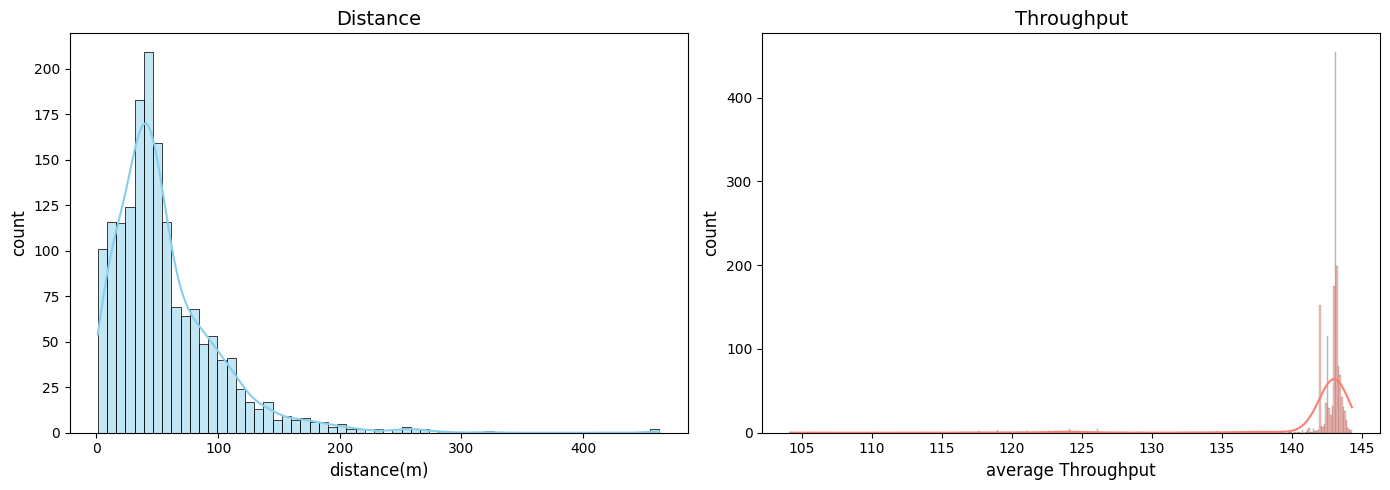

✅ 거리 클리핑: 10% ~ 90% 범위 적용
✅ 처리율 클리핑: 30% ~ 70% 범위 적용

--- After Clipping ---
✅ 거리 (m) 평균: 52.662, 표준편차: 31.240
✅ 평균 처리율 평균: 142.974, 표준편차: 0.181


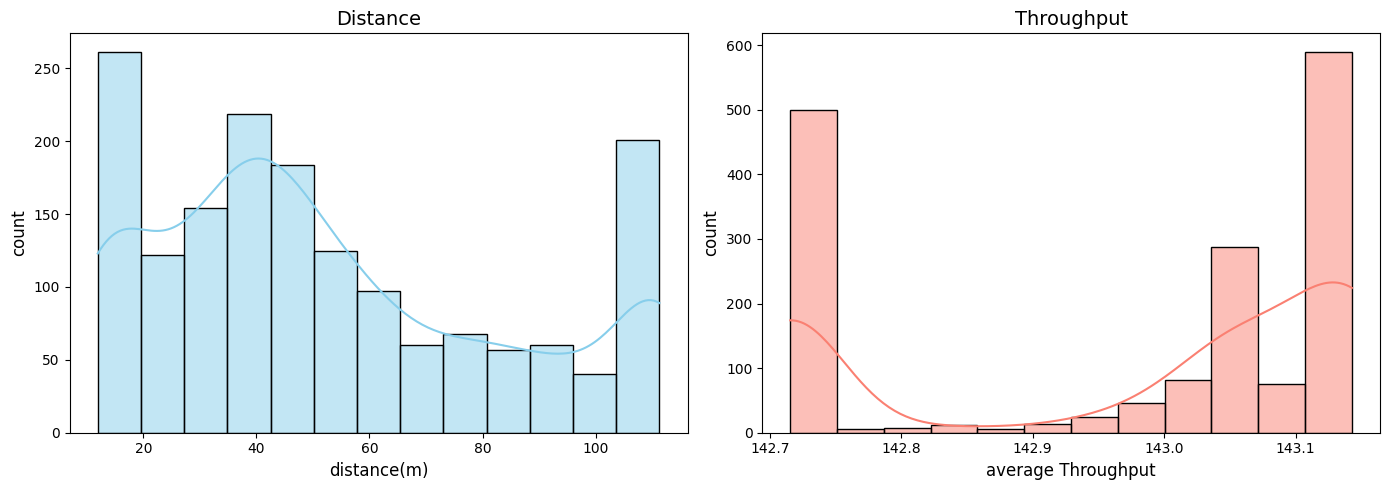

✅ Distance 정규화 범위: 0.000 ~ 1.000
✅ Throughput 정규화 범위: 0.000 ~ 1.000


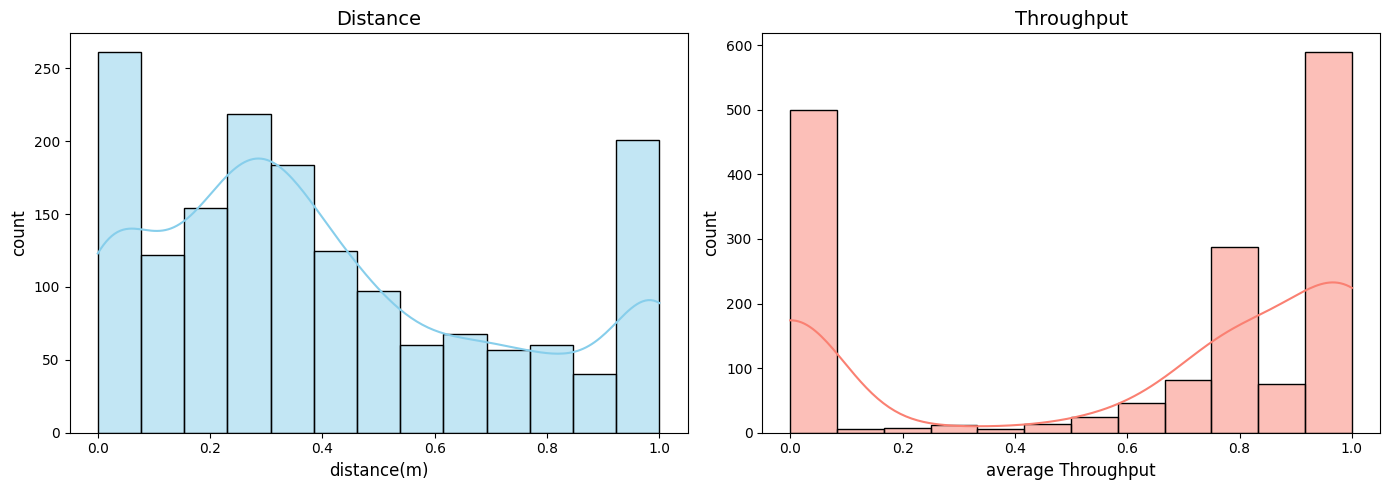


--- After Normalization ---
✅ distance_norm 평균: 0.410, 표준편차: 0.314
✅ throughput_norm 평균: 0.604, 표준편차: 0.423


In [ ]:
# 데이터 전처리 (표준화 제거, 클리핑 → 정규화)

# 1. 엑셀 파일 로드
file_path = r"g:\내 드라이브\[4학년]\[졸업 작품]\edges_distance_throughput.xlsx"
df = pd.read_excel(file_path)

# 2. 원본 데이터 분석
print_mean_std(df, "거리 (m)", "평균 처리율", step_desc="Original Data")
plot_distribution(df, distance_col="거리 (m)", throughput_col="평균 처리율")

# 3. 클리핑
df_clipped = clip_custom(df, "거리 (m)", "평균 처리율", dist_quantile=0.10, thr_quantile=0.3)
print_mean_std(df_clipped, "거리 (m)", "평균 처리율", step_desc="After Clipping")
plot_distribution(df_clipped, distance_col="거리 (m)", throughput_col="평균 처리율")

# 4. 정규화
df_norm = normalize_data(df_clipped, distance_col="거리 (m)", throughput_col="평균 처리율")

# 5. 정규화 후 시각화
plot_distribution(df_norm, distance_col="distance_norm", throughput_col="throughput_norm")
print_mean_std(df_norm, "distance_norm", "throughput_norm", step_desc="After Normalization")



In [ ]:
# 전처리된 데이터 저장

def export_clipped_data_with_nodes_to_excel(df,
                                            output_filename="clipped_distance_throughput.xlsx",
                                            source_col="출발 노드",
                                            target_col="도착 노드",
                                            norm_distance_col="distance_norm",
                                            norm_throughput_col="throughput_norm"):
    # 필요한 열만 추출
    df_to_export = df[[source_col, target_col, norm_distance_col, norm_throughput_col]].copy()
    df_to_export.columns = ["출발 노드", "도착 노드", "Distance (Normalized)", "Throughput (Normalized)"]

    # 평균값 계산
    avg_distance = df_to_export["Distance (Normalized)"].replace(0, pd.NA).mean()
    avg_throughput = df_to_export["Throughput (Normalized)"].replace(0, pd.NA).mean()

    # 처리율이 0.99 이상 또는 0.01 이하인 경우 평균으로 대체
    df_to_export.loc[
        (df_to_export["Throughput (Normalized)"] >= 0.95) |
        (df_to_export["Throughput (Normalized)"] <= 0.05),
        "Throughput (Normalized)"
    ] = avg_throughput

    # 거리가 0.95 이상 또는 0.01 이하인 경우 평균으로 대체
    df_to_export.loc[
        (df_to_export["Distance (Normalized)"] >= 0.95) |
        (df_to_export["Distance (Normalized)"] <= 0.05),
        "Distance (Normalized)"
    ] = avg_distance

    # 엑셀로 저장
    df_to_export.to_excel(output_filename, index=False)
    print(avg_distance,avg_throughput)
    print(f"✅ 엑셀 파일로 저장 완료: {output_filename}")


# 함수 호출
export_clipped_data_with_nodes_to_excel(
    df_norm,
    output_filename="clipped_distance_throughput.xlsx",
    source_col="출발 노드",
    target_col="도착 노드",
    norm_distance_col="distance_norm",
    norm_throughput_col="throughput_norm"
)


0.4554508467351919 0.8635684939909456
✅ 엑셀 파일로 저장 완료: clipped_distance_throughput.xlsx


In [ ]:
# 최종 파일
import pandas as pd

# 파일 경로
edges_file = r"g:\내 드라이브\[4학년]\[졸업 작품]\edges_distance_throughput.xlsx"
clipped_file = r"g:\내 드라이브\[4학년]\[졸업 작품]\clipped_distance_throughput.xlsx"
output_file = r"g:\내 드라이브\[4학년]\[졸업 작품]\Final_edges_values.xlsx"

# 엑셀 읽기
edges_df = pd.read_excel(edges_file)
clipped_df = pd.read_excel(clipped_file)

# clipped 데이터에서 필요한 열만 추출 (출발/도착 노드를 기준으로)
merge_cols = ["출발 노드", "도착 노드", "Distance (Normalized)", "Throughput (Normalized)"]
clipped_df_subset = clipped_df[merge_cols]

# 병합 (출발 노드 + 도착 노드 기준)
merged_df = edges_df.merge(
    clipped_df_subset,
    how='left',
    left_on=["출발 노드", "도착 노드"],
    right_on=["출발 노드", "도착 노드"]
)

# Throughput (Inverted) 열 추가
merged_df["Throughput (Inverted)"] = 1 - merged_df["Throughput (Normalized)"]

# 엑셀로 저장
merged_df.to_excel(output_file, index=False)

output_file


'g:\\내 드라이브\\[4학년]\\[졸업 작품]\\Final_edges_values.xlsx'

## 전처리된 데이터로 경로찾기

- clipped_distance_throughput의 전처리된 데이터를 edges_distance_throughput에 추가

In [ ]:
# 엑셀 comm data(throughput) 불러오기
throughput_excel = pd.read_excel(r"g:\내 드라이브\[4학년]\[졸업 작품]\Final_edges_values.xlsx")

In [ ]:
# 전처리 후 처리율, 거리 시각화

from matplotlib import cm, colors

# 엑셀 로드
df = pd.read_excel(r"g:\내 드라이브\[4학년]\[졸업 작품]\Final_edges_values.xlsx")

def get_coord(node_id, rx_coord_dict, backup_graph):
    node = backup_graph.nodes.get(node_id)
    if node:
        return node.get('y'), node.get('x')  # 위도, 경도
    return rx_coord_dict.get(node_id)

distance_cmap = cm.get_cmap('Blues')
throughput_cmap = cm.get_cmap('Reds')
norm = colors.Normalize(vmin=0, vmax=1)

# 지도 1️⃣ 거리만 시각화
m_distance = folium.Map(location=[36.6, 127.5], zoom_start=13)
rx_coord_dict = {node: (data['y'], data['x']) for node, data in cheongju_graph.nodes(data=True)}

for idx, row in df.iterrows():
    u = row['출발 노드']
    v = row['도착 노드']
    distance_norm = row['Distance (Normalized)']

    coord_u = get_coord(u, rx_coord_dict, cheongju_graph)
    coord_v = get_coord(v, rx_coord_dict, cheongju_graph)
    if None in (coord_u, coord_v):
        continue

    dist_color = colors.to_hex(distance_cmap(norm(distance_norm)))
    folium.PolyLine(
        locations=[coord_u, coord_v],
        color=dist_color,
        weight=5,
        opacity=0.7,
        tooltip=f"Distance Norm: {distance_norm:.2f}"
    ).add_to(m_distance)

print("✅ 거리 지도 준비 완료")
m_distance  # 실행창에 바로 출력

# 지도 2️⃣ 처리율만 시각화
m_throughput = folium.Map(location=[36.6, 127.5], zoom_start=13)

for idx, row in df.iterrows():
    u = row['출발 노드']
    v = row['도착 노드']
    throughput_inv = row['Throughput (Inverted)']

    coord_u = get_coord(u, rx_coord_dict, cheongju_graph)
    coord_v = get_coord(v, rx_coord_dict, cheongju_graph)
    if None in (coord_u, coord_v):
        continue

    thrpt_color = colors.to_hex(throughput_cmap(norm(throughput_inv)))
    folium.PolyLine(
        locations=[coord_u, coord_v],
        color=thrpt_color,
        weight=5,
        opacity=0.7,
        tooltip=f"Throughput Inverted: {throughput_inv:.2f}"
    ).add_to(m_throughput)

print("✅ 처리율 지도 준비 완료")
m_throughput  # 실행창에 바로 출력

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8248\2769081278.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  distance_cmap = cm.get_cmap('Blues')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_8248\2769081278.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  throughput_cmap = cm.get_cmap('Reds')


✅ 거리 지도 준비 완료
✅ 처리율 지도 준비 완료


In [ ]:
m_distance

In [ ]:
# 가중치 계산 함수 (전처리 후)
def calculate_weight(throughput, distance, ratio):
    """
    - throughput : Throughput 값
    - distance   : distance 값
    - ratio      : Throughput과 거리의 비율 (0~1)
    """
    weight = (ratio * distance) + ((1 - ratio) * throughput)
    return weight

In [ ]:
# 가중치 노드 매핑 함수
def set_edge_weights_based_on_ratio_with_excel(G, ratio, df_excel,
                                               source_col="출발 노드",
                                               target_col="도착 노드",
                                               distance_col="Distance (Normalized)",
                                               throughput_col="Throughput (Inverted)"):
    updated_count = 0

    excel_lookup = {}
    for _, row in df_excel.iterrows():
        u = row[source_col]
        v = row[target_col]
        distance = row[distance_col]
        throughput = row[throughput_col]


        excel_lookup[(u, v)] = (distance, throughput)
        excel_lookup[(v, u)] = (distance, throughput)

    for u, v, data in G.edges(data=True):
        if (u, v) in excel_lookup:
            distance, throughput = excel_lookup[(u, v)]
            weight = calculate_weight(throughput, distance, ratio)  # 함수 호출로 변경
            if pd.isna(weight):
                weight = float('inf')
            else:
                weight = max(weight, 0)

            data['weight'] = weight
            updated_count += 1
        else:
            data['weight'] = float('inf')



    print(f"{updated_count}개의 엣지에 가중치를 업데이트 완료했습니다.")
    return G


In [ ]:
# 노드를 찾는 함수
def get_node_coordinates(node_id, rx_coord_dict, backup_graph):
    """
    node_id: 노드 ID
    rx_coord_dict: {노드ID: (위도, 경도)} 형태의 딕셔너리
    backup_graph: networkx/OSMnx 그래프 객체
    반환: (경도, 위도) 튜플 또는 (None, None)
    """
    node_data = backup_graph.nodes.get(node_id)
    if node_data:
        lon = node_data.get('x')
        lat = node_data.get('y')
        if lon is not None and lat is not None:
            return lon, lat

    # backup_graph에 없으면 rx_coord_dict에서 찾기
    coord = rx_coord_dict.get(node_id)
    if coord:
        lat, lon = coord  # dict는 (위도, 경도)이므로 순서 바꿔줌
        return lon, lat

    return None, None


In [ ]:
# folium 시각화 함수
from branca.element import Template, MacroElement

def plot_multiple_paths_on_real_map(paths_dict, rx_coord_dict, backup_graph, origin_node, destination_node, colors=None, title="Throughput 기반 경로 실지도 시각화"):
    """
    - paths_dict: {비율: 경로 리스트} 형식의 딕셔너리
    - rx_coord_dict: Rx 노드 좌표 딕셔너리
    - backup_graph: 중간 노드 좌표 (cheongju_graph)
    - origin_node: 출발 노드 ID
    - destination_node: 도착 노드 ID
    - colors: 비율 리스트에 대응하는 색상 리스트
    - title: 지도 제목
    """
    if colors is None:
        colors = ['red', 'blue', 'green', 'purple', 'orange', 'pink', 'brown']

    # 출발지 좌표로 지도 초기화
    start_lon, start_lat = get_node_coordinates(origin_node, rx_coord_dict, backup_graph)
    m = folium.Map(location=[start_lat, start_lon], zoom_start=15)

    legend_html_entries = []  # 범례에 들어갈 내용 저장용

    # 경로들 추가
    for idx, (ratio, path) in enumerate(paths_dict.items()):
        if path is None:
            continue

        path_coordinates = []
        for node_id in path:
            lon, lat = get_node_coordinates(node_id, rx_coord_dict, backup_graph)
            if None not in (lon, lat):
                path_coordinates.append((lat, lon))

        # 지도에 경로 추가
        color = colors[idx % len(colors)]
        folium.PolyLine(
            locations=path_coordinates,
            color=color,
            weight=5,
            opacity=0.8,
            popup=f"비율 {ratio:.1f}:{1-ratio:.1f}"
        ).add_to(m)

        # 범례용 항목 추가
        legend_html_entries.append(f'<li><span style="background:{color};width:20px;height:10px;display:inline-block;margin-right:5px;"></span> 처리율:{ratio:.1f} / 거리:{1-ratio:.1f}</li>')

    # 출발지 마커
    start_coords = get_node_coordinates(origin_node, rx_coord_dict, backup_graph)
    folium.Marker(
        location=(start_coords[1], start_coords[0]),
        popup="Origin",
        icon=folium.Icon(color='red', icon='play')
    ).add_to(m)

    # 도착지 마커
    end_coords = get_node_coordinates(destination_node, rx_coord_dict, backup_graph)
    folium.Marker(
        location=(end_coords[1], end_coords[0]),
        popup="Destination",
        icon=folium.Icon(color='green', icon='flag')
    ).add_to(m)

    # 범례 추가 (HTML)
    legend_html = f"""
    <div style="
        position: fixed;
        bottom: 50px;
        left: 50px;
        width: 220px;
        height: auto;
        z-index:9999;
        font-size:14px;
        background: white;
        border:2px solid gray;
        border-radius:6px;
        padding: 10px;
        box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
    ">
        <b>{title}</b>
        <ul style="list-style: none; padding-left: 0; margin: 10px 0 0 0;">
            {''.join(legend_html_entries)}
        </ul>
    </div>
    """
    legend = MacroElement()
    legend._template = Template(legend_html)
    m.get_root().add_child(legend)

    return m


In [ ]:
# 경로가 다른 가중치 비율 찾기
ratios = [i/1000 for i in range(0, 1001, 5)]  # 0, 0.005, 0.010, ..., 1.0
unique_paths = []
paths_result = {}

for ratio in ratios:
    #print(f"\n🔄 비율 {ratio:.3f}:{1 - ratio:.3f} 가중치 계산 중...")

    G_temp = set_edge_weights_based_on_ratio_with_excel(
        G_set_node.copy(),
        ratio=ratio,
        df_excel=throughput_excel,
        source_col="출발 노드",
        target_col="도착 노드",
        distance_col="Distance (Normalized)",
        throughput_col="Throughput (Normalized)"
    )

    try:
        path = nx.shortest_path(G_temp, source=origin_node, target=destination_node, weight='weight', method='dijkstra')
        path_tuple = tuple(path)

        # 새로운 경로인지 확인
        if path_tuple not in unique_paths:
            unique_paths.append(path_tuple)
            paths_result[ratio] = path
            print(f"✅ 새로운 경로 발견! 비율 {ratio:.3f} → 경로: {path}")

    except nx.NetworkXNoPath:
        print("❌ 경로를 찾을 수 없습니다.")

# 결과 요약 출력
print("\n=== 최종 서로 다른 경로 ===")
for i, (ratio, path) in enumerate(paths_result.items(), 1):
    print(f"{i}. 비율 {ratio:.3f}: 경로 {path}")


1648개의 엣지에 가중치를 업데이트 완료했습니다.
✅ 새로운 경로 발견! 비율 0.000 → 경로: [8485871892, 11535631438, 11535631437, 4657179295, 5370128281, 3015872402, 2272245177, 3791819479, 1621248629, 2271378269, 4679763988, 4657247656, 2260052923, 2918310206, 1806881875, 2260052845, 3957495727, 4670424839, 4657150752, 4670424838, 2269006369, 4682813858, 3957495728, 4657375587, 437043951, 12609615257, 2269006354, 4641476304, 4866000800, 2269006367, 4866000799, 437043957, 4756176364, 4688753329, 4639588742, 4641480587, 4656460777, 2967848549, 3958352335, 6200628380]
1648개의 엣지에 가중치를 업데이트 완료했습니다.
✅ 새로운 경로 발견! 비율 0.005 → 경로: [8485871892, 8485871893, 4679820440, 4679820439, 5370128281, 3015872402, 2272245177, 3791819479, 1621248629, 2271378269, 4679763988, 4657247656, 2260052923, 2918310206, 1806881875, 2260052845, 3957495727, 4670424839, 4657150752, 4670424838, 2269006369, 4682813858, 3957495728, 4657375587, 437043951, 12609615257, 2269006354, 4641476304, 4866000800, 2269006367, 4866000799, 437043957, 4756176364, 46887533

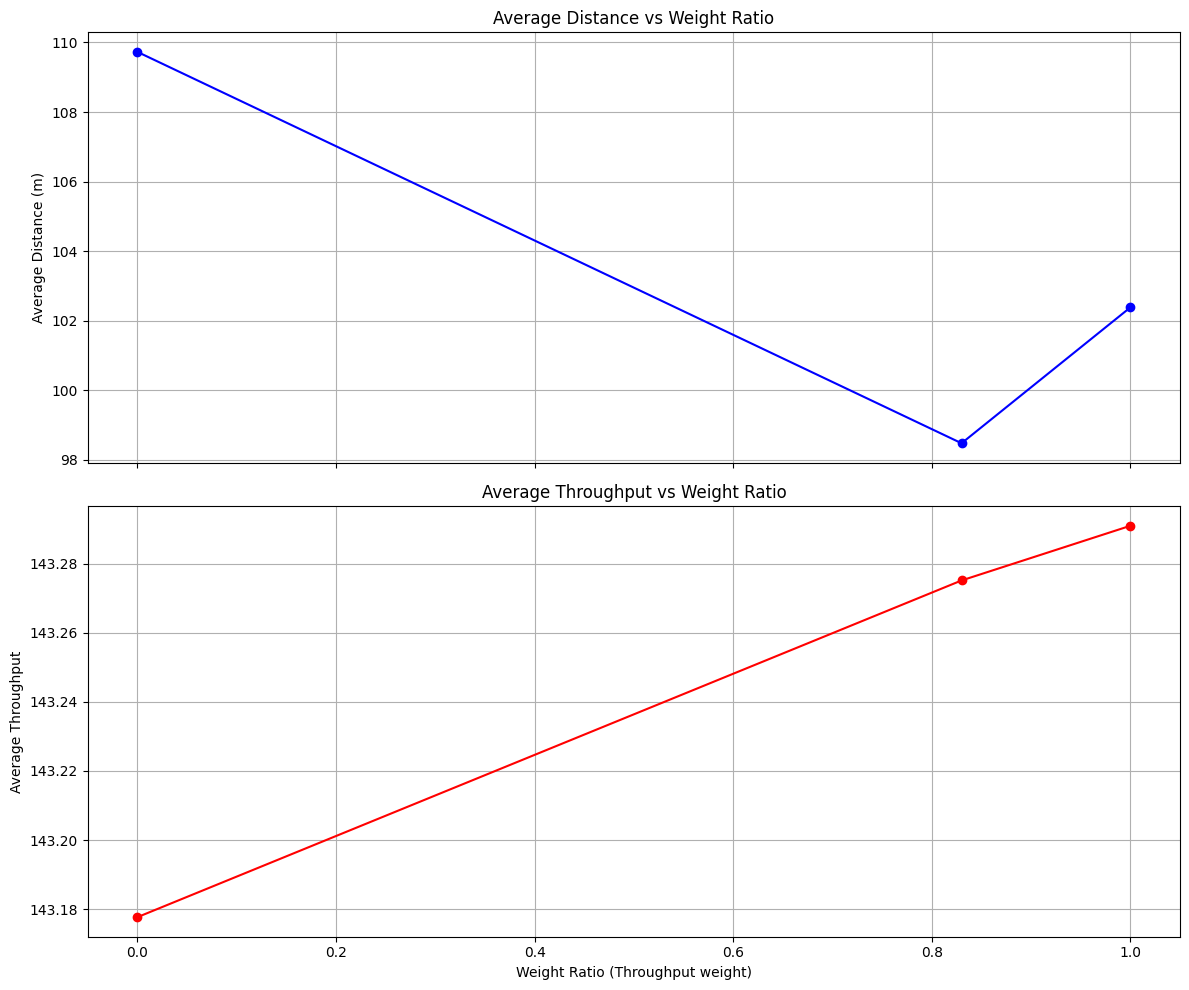

In [ ]:
# 가중치 비율에 따른 처리율, 거리 그래프
avg_distances = []
avg_throughputs = []
ratios_list = []

for ratio, path in paths_result.items():
    total_distance = 0
    total_throughput = 0
    count = 0

    for u, v in zip(path[:-1], path[1:]):
        row = throughput_excel[((throughput_excel['출발 노드'] == u) & (throughput_excel['도착 노드'] == v)) |
                               ((throughput_excel['출발 노드'] == v) & (throughput_excel['도착 노드'] == u))]

        if not row.empty:
            distance = row.iloc[0]['거리 (m)']  # ✅ 원본 데이터의 거리
            throughput = row.iloc[0]['평균 처리율']  # ✅ 원본 데이터의 처리율
            total_distance += distance
            total_throughput += throughput
            count += 1

    if count > 0:
        avg_distance = total_distance / count
        avg_throughput = total_throughput / count
    else:
        avg_distance = None
        avg_throughput = None

    avg_distances.append(avg_distance)
    avg_throughputs.append(avg_throughput)
    ratios_list.append(ratio)

# ✅ 그래프 그리기
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Distance plot
axes[0].plot(ratios_list, avg_distances, marker='o', color='blue')
axes[0].set_ylabel('Average Distance (m)')
axes[0].set_title('Average Distance vs Weight Ratio')
axes[0].grid(True)

# Throughput plot
axes[1].plot(ratios_list, avg_throughputs, marker='o', color='red')
axes[1].set_xlabel('Weight Ratio (Throughput weight)')
axes[1].set_ylabel('Average Throughput')
axes[1].set_title('Average Throughput vs Weight Ratio')
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
ratios = [0.3,0.830,1.0]
paths_result = {}

for ratio in ratios:
    print(f"\n🔄 비율 {ratio:.1f}:{1 - ratio:.1f} 가중치 계산 중...")
    G_temp = set_edge_weights_based_on_ratio_with_excel(
        G_set_node.copy(),
        ratio=ratio,
        df_excel=throughput_excel,
        source_col="출발 노드",
        target_col="도착 노드",
        distance_col="Distance (Normalized)",
        throughput_col="Throughput (Normalized)"
    )

    try:
        path = nx.shortest_path(G_temp, source=origin_node, target=destination_node, weight='weight', method='dijkstra')
        paths_result[ratio] = path
        print(f"✅ 경로: {path}")
    except nx.NetworkXNoPath:
        print("❌ 경로를 찾을 수 없습니다.")



🔄 비율 0.3:0.7 가중치 계산 중...
1648개의 엣지에 가중치를 업데이트 완료했습니다.
✅ 경로: [8485871892, 8485871893, 4679820440, 4679820439, 5370128281, 3015872402, 2272245177, 3791819479, 1621248629, 2271378269, 4679763988, 4657247656, 2260052923, 2918310206, 1806881875, 2260052845, 3957495727, 4670424839, 4657150752, 4670424838, 2269006369, 4682813858, 3957495728, 4657375587, 437043951, 12609615257, 2269006354, 4641476304, 4866000800, 2269006367, 4866000799, 437043957, 4756176364, 4688753329, 4639588742, 4641480587, 4656460777, 2967848549, 3958352335, 6200628380]

🔄 비율 0.8:0.2 가중치 계산 중...
1648개의 엣지에 가중치를 업데이트 완료했습니다.
✅ 경로: [8485871892, 11535631438, 11535631430, 8046191321, 2272245105, 2260052868, 2260052855, 11861135647, 11861135635, 2260052826, 2260052794, 414917883, 4657257284, 2271377821, 4657301899, 2271377877, 2271377926, 4657247632, 4657247637, 3957495727, 4670424839, 4670424837, 4670424838, 2269006369, 4682813858, 3957495728, 4657375587, 437043951, 12609615257, 2269006354, 4641476304, 4866000800, 2269006367

In [ ]:
# 1️⃣ 비율별 경로 딕셔너리 준비
paths_dict = {ratio: paths_result.get(ratio) for ratio in ratios}

# 2️⃣ 색상 리스트 (원하는 색 순서 지정)
colors = ['red', 'purple', 'green', 'blue']  # 0.0, 0.3, 0.6, 1.0 순서

# 3️⃣ 지도 생성
multi_path_map = plot_multiple_paths_on_real_map(
    paths_dict=paths_dict,
    rx_coord_dict=rx_coord_dict,
    backup_graph=cheongju_graph,
    origin_node=origin_node,
    destination_node=destination_node,
    colors=colors,
    title="Throughput 기반 최적 경로 실지도 시각화"
)

# 4️⃣ 결과 출력
multi_path_map


- 다른 방식의 시각화

In [ ]:
pip install matplotlib-scalebar


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


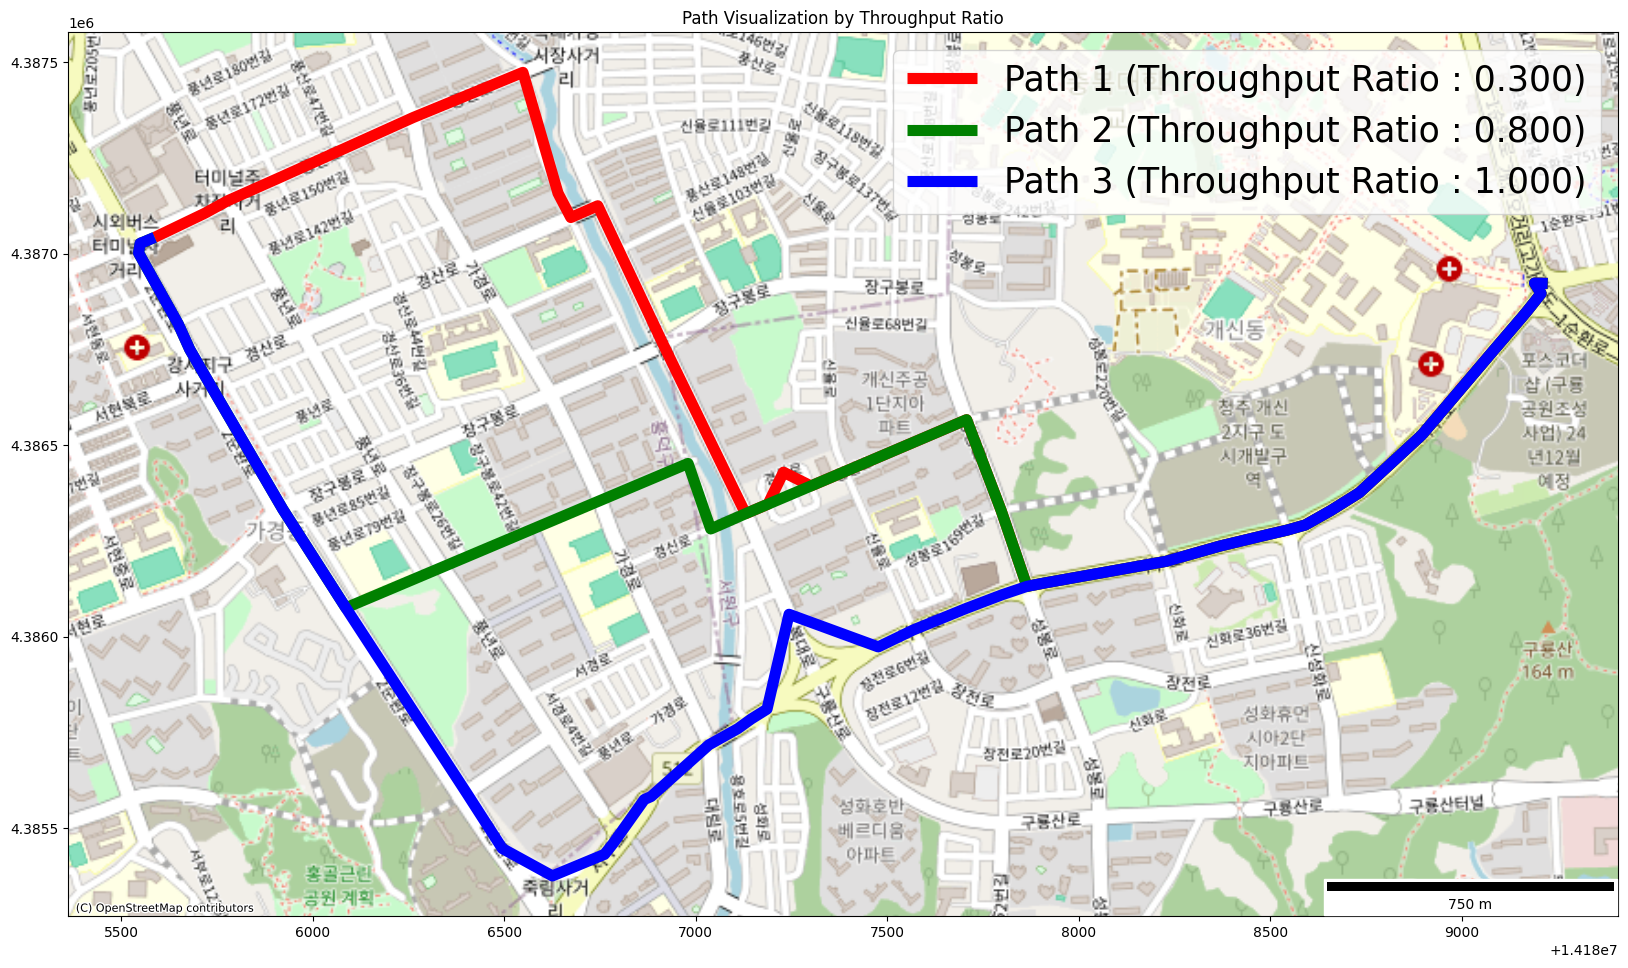

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from shapely.geometry import LineString
from matplotlib_scalebar.scalebar import ScaleBar  # 스케일바 추가

# 1️⃣ LineString 리스트 만들기
import math  # 추가

lines = []
labels = []  # 각 경로의 비율을 저장
for idx, (ratio, path) in enumerate(paths_result.items()):
    coords = []
    for node in path:
        coord = rx_coord_dict.get(node)
        if coord is None:
            coord = (rx_nodes.nodes[node]['y'], rx_nodes.nodes[node]['x'])
        coords.append((coord[1], coord[0]))  # (lon, lat)
    lines.append(LineString(coords))

    # 소수점 3자리에서 반내림
    floored_ratio = math.floor(ratio * 10) / 10
    labels.append(f"Path {idx+1} (Throughput Ratio : {floored_ratio:.3f})")


# 2️⃣ GeoDataFrame 생성
gdf = gpd.GeoDataFrame({'label': labels, 'geometry': lines}, crs='EPSG:4326')
gdf = gdf.to_crs(epsg=3857)  # 웹 맵 타일 좌표계로 변환

# 3️⃣ 그림/축 생성 (사이즈 크게 → 20 x 22)
fig, ax = plt.subplots(figsize=(20, 22))

# 4️⃣ 색상 매핑: 경로1=빨강, 경로2=초록, 경로3=파랑
color_map = ['red', 'green', 'blue']

for idx, row in gdf.iterrows():
    color = color_map[idx % len(color_map)]  # 경로 수가 3개 초과 시 반복
    gpd.GeoSeries(row['geometry']).plot(ax=ax, linewidth=8, color=color, label=row['label'])  # linewidth=8로 더 굵게

# 5️⃣ 지도 범위 (padding → 0.05로 축소 → 더 좁게 보기)
xmin, ymin, xmax, ymax = gdf.total_bounds
pad_x = (xmax - xmin) * 0.05
pad_y = (ymax - ymin) * 0.05
ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 6️⃣ basemap 추가
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# 7️⃣ 스케일바 추가
scalebar = ScaleBar(dx=1, units='m', location='lower right')  # 3857 좌표계 → m
ax.add_artist(scalebar)

# 8️⃣ 범례 추가
ax.legend(loc='upper right', prop={'size':25})

plt.title("Path Visualization by Throughput Ratio")
plt.show()


## 소요시간 계산

In [ ]:
# 새 엑셀 데이터 불러오기
throughput_excel_original = pd.read_excel(r"g:\내 드라이브\[4학년]\[졸업 작품]\Final_edges_values.xlsx")


In [ ]:
!pip install haversine


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from haversine import haversine

def calculate_distance(u, v, rx_coord_dict, backup_graph):
    lon1, lat1 = get_node_coordinates(u, rx_coord_dict, backup_graph)
    lon2, lat2 = get_node_coordinates(v, rx_coord_dict, backup_graph)

    if None not in (lon1, lat1, lon2, lat2):
        distance_km = haversine((lat1, lon1), (lat2, lon2))
        return distance_km * 1000  # meter 변환
    else:
        return float('inf')


def estimate_travel_time_simple(total_distance_meters):
    """
    거리만으로 소요시간 계산 (고정 속도 30km/h)
    """
    base_speed = 33.4
    speed_mps = base_speed * 1000 / 3600  # km/h → m/s 변환

    move_time_seconds = total_distance_meters / speed_mps
    move_time_minutes = move_time_seconds / 60

    return move_time_seconds, move_time_minutes, base_speed


def summarize_single_path(G, path, ratio_label):
    num_nodes = len(path)
    total_distance = 0
    throughput_list = []

    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]

        if G.has_edge(u, v):
            edge_data = G[u][v]
            distance = edge_data.get('length', None)

            if distance is None:
                distance = calculate_distance(u, v, rx_coord_dict, cheongju_graph)

            throughput_u = G.nodes[u].get('throughput', 0)
            throughput_v = G.nodes[v].get('throughput', 0)
            avg_throughput = (throughput_u + throughput_v) / 2

            total_distance += distance
            throughput_list.append(avg_throughput)

    if throughput_list:
        avg_throughput = sum(throughput_list) / len(throughput_list)
        # min_throughput = min(throughput_list)
        # max_throughput = max(throughput_list)
    else:
        avg_throughput = min_throughput = max_throughput = 0

    # 소요시간 계산
    time_sec, time_min, base_speed = estimate_travel_time_simple(total_distance)

    # 출력
    print(f"\n🚗 비율 {ratio_label} 경로 요약:")
    print(path)
    print(f" - 노드 수: {num_nodes}")
    print(f" - 총 거리: {total_distance:.2f} m")
    print(f" - 기본 속도: {base_speed} km/h")
    print(f" - 소요 시간: {time_sec:.1f}초 ≈ {time_min:.1f}분")
    print(f" - 평균 처리율: {avg_throughput:.2f}")
    #print(f" - 최소 처리율: {min_throughput:.2f}")
    #print(f" - 최대 처리율: {max_throughput:.2f}")


# ✅ 단일 반복문 (시간대 없이)
for ratio in [0.3, 0.83, 1.0]:
    path = paths_result.get(ratio)
    if path:
        summarize_single_path(G_set_node, path, f"{ratio:.1f}:{1-ratio:.1f}")



🚗 비율 0.3:0.7 경로 요약:
[8485871892, 8485871893, 4679820440, 4679820439, 5370128281, 3015872402, 2272245177, 3791819479, 1621248629, 2271378269, 4679763988, 4657247656, 2260052923, 2918310206, 1806881875, 2260052845, 3957495727, 4670424839, 4657150752, 4670424838, 2269006369, 4682813858, 3957495728, 4657375587, 437043951, 12609615257, 2269006354, 4641476304, 4866000800, 2269006367, 4866000799, 437043957, 4756176364, 4688753329, 4639588742, 4641480587, 4656460777, 2967848549, 3958352335, 6200628380]
 - 노드 수: 40
 - 총 거리: 4203.62 m
 - 기본 속도: 33.4 km/h
 - 소요 시간: 453.1초 ≈ 7.6분
 - 평균 처리율: 139.55

🚗 비율 0.8:0.2 경로 요약:
[8485871892, 11535631438, 11535631430, 8046191321, 2272245105, 2260052868, 2260052855, 11861135647, 11861135635, 2260052826, 2260052794, 414917883, 4657257284, 2271377821, 4657301899, 2271377877, 2271377926, 4657247632, 4657247637, 3957495727, 4670424839, 4670424837, 4670424838, 2269006369, 4682813858, 3957495728, 4657375587, 437043951, 12609615257, 2269006354, 4641476304, 486600080